# EDA – Old Assyrian (Akkadian) Translation Dataset
**Dataset:** `train.csv` (1561 rows)  
**Columns:** `oare_id` | `transliteration` | `translation`

This notebook explores the **raw** data before any cleaning.  
Nothing is modified here - all fixes live in `preprocessing.py`.


## Imports and loading

In [34]:
import re
import unicodedata
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/train.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)


Shape: (1561, 3)
Columns: ['oare_id', 'transliteration', 'translation']


,oare_id,transliteration,translation
0,004a7dbd-57ce-46f8-9691-409be61c676e,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ..."
1,0064939c-59b9-4448-a63d-34612af0a1b5,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...
2,0073f2c0-524c-4bbf-915a-8c1772a4fb98,TÚG u-la i-dí-na-ku-um i-tù-ra-ma 9 GÍN KÙ.BABBAR,<gap> he did not give you a textile. He return...


## Null/empty check

In [35]:
print(f"Null counts: {df.isnull().sum()}\n")

print(f"Empty-string transliterations: {(df['transliteration'] == '').sum()}\n")
print(f"Empty-string translations: {(df['translation'] == '').sum()}\n")

Null counts: oare_id            0
transliteration    0
translation        0
dtype: int64

Empty-string transliterations: 0

Empty-string translations: 0



## Length Statistics

In [36]:
df['translit_len'] = df['transliteration'].str.len()
df['transl_len'] = df['translation'].str.len()
df['len_ratio'] = df['transl_len'] / df['translit_len'].replace(0, 1)  # to avoid division by 0

print(df[['translit_len', 'transl_len', 'len_ratio']].describe())

       translit_len   transl_len    len_ratio
count   1561.000000  1561.000000  1561.000000
mean     428.819987   500.418962     1.089983
std      270.432342   467.486948     0.492851
min       21.000000     6.000000     0.011472
25%      206.000000   174.000000     0.981043
50%      371.000000   383.000000     1.081050
75%      636.000000   680.000000     1.184211
max      966.000000  3995.000000     9.245675


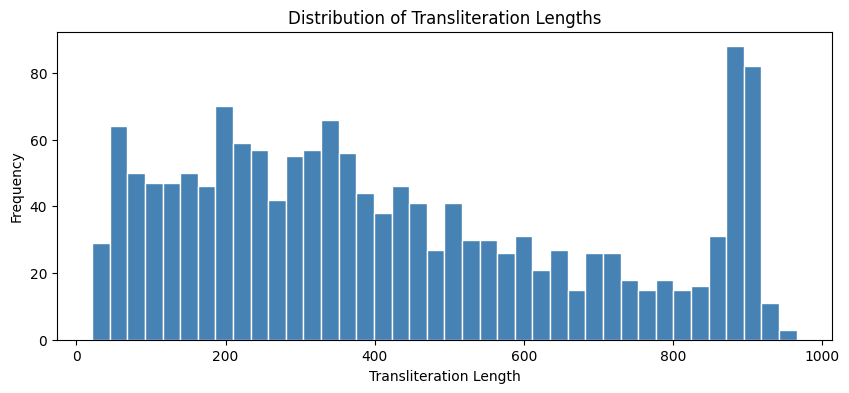

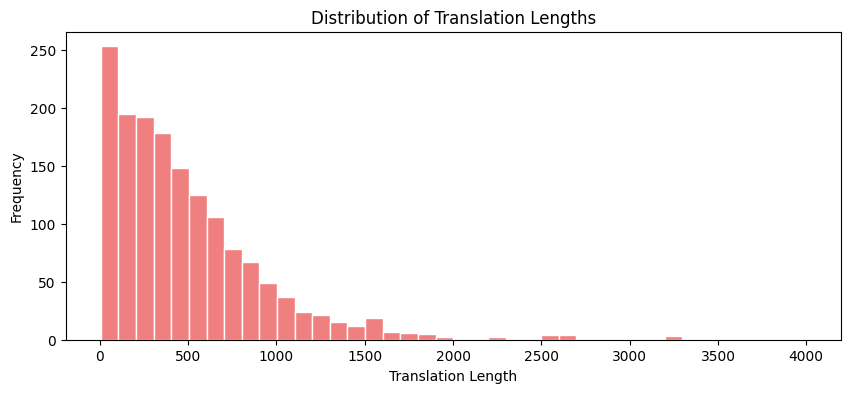

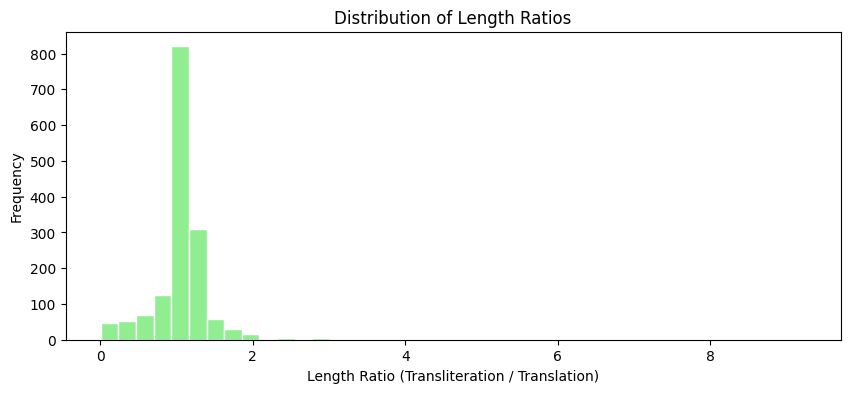

In [37]:
plt.figure(figsize=(10, 4))
plt.hist(df['translit_len'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Transliteration Length')
plt.ylabel('Frequency')
plt.title('Distribution of Transliteration Lengths')
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df['transl_len'], bins=40, color='lightcoral', edgecolor='white')
plt.xlabel('Translation Length')
plt.ylabel('Frequency')
plt.title('Distribution of Translation Lengths')
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df['len_ratio'], bins=40, color='lightgreen', edgecolor='white')
plt.xlabel('Length Ratio (Transliteration / Translation)')
plt.ylabel('Frequency')
plt.title('Distribution of Length Ratios')
plt.show()

## Duplicates

In [38]:
print(f"Duplicate oare_id: {df['oare_id'].duplicated().sum()}")
print(f"Duplicate transliterations: {df['transliteration'].duplicated().sum()}")
print(f"Duplicate translations: {df['translation'].duplicated().sum()}")

Duplicate oare_id: 0
Duplicate transliterations: 2
Duplicate translations: 4


We want to show the duplicate transliteration pairs.

In [39]:
dup_t = df[df['transliteration'].duplicated(keep=False)].sort_values('transliteration')
print(f"{len(dup_t)} rows share a transliteration with another row:\n")
dup_t[['oare_id', 'transliteration']].style.set_properties(**{'text-align': 'left'})


4 rows share a transliteration with another row:



,oare_id,transliteration
719,71f57016-ddcb-4e25-bb13-c2214c1c9921,40 ma-na KÙ.BABBAR ni-is-ḫa-sú DIRI ša-du-a-sú ša-bu en-um-a-šùr a-na a-lu-a ù e-ni-ša-ru-um i-na ša-la-tù-ar ku-nu-ki ip-qí-id um-ma šu-ut-ma a-na a-lim{ki} a-na ša-lim-a-šur a-bi-a bi-lá ú 5 GÍN KÙ.BABBAR a-na qá-tí-šu-nu i-dí-in a-na a-wa-tim a-ni-a-tim kà-ru-um wa-aḫ-šu-ša-na i-dí-in-ni-a-tí-ma IGI GÍR ša da-šùr ší-bu-tí-ni ni-dí-in IGI ili₅-ba-ni DUMU a-mur-a-šur IGI a-ḫu-wa-qar DUMU šu-IŠTAR tù-ra-am-ì-lí DUMU e-dí-in-a-šur tap-pá-i-ni
1271,cc4f9021-bfb5-49ca-afe0-91e5d073d38a,40 ma-na KÙ.BABBAR ni-is-ḫa-sú DIRI ša-du-a-sú ša-bu en-um-a-šùr a-na a-lu-a ù e-ni-ša-ru-um i-na ša-la-tù-ar ku-nu-ki ip-qí-id um-ma šu-ut-ma a-na a-lim{ki} a-na ša-lim-a-šur a-bi-a bi-lá ú 5 GÍN KÙ.BABBAR a-na qá-tí-šu-nu i-dí-in a-na a-wa-tim a-ni-a-tim kà-ru-um wa-aḫ-šu-ša-na i-dí-in-ni-a-tí-ma IGI GÍR ša da-šùr ší-bu-tí-ni ni-dí-in IGI ili₅-ba-ni DUMU a-mur-a-šur IGI a-ḫu-wa-qar DUMU šu-IŠTAR tù-ra-am-ì-lí DUMU e-dí-in-a-šur tap-pá-i-ni
1045,a793a223-aa10-411f-8240-a1fc160fcf12,i-dí-a-bu-um É-tí ša bu-ri-im a-šar ša-lim-a-šùr wa-áš-bu iš-tí tù-ud-ḫa-li-a a-ḫu tù-li iš-a-am a-na a-wa-tim a-ni-a-tim kà-ru-um kà-ni-iš i-dí-ni-a-tí-ma ṭup-pá-am ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in IGI a-ku-za IGI ú-ra-a IGI a-šùr-ba-ni
1242,c596eed5-49f6-4a97-8201-35764873f452,i-dí-a-bu-um É-tí ša bu-ri-im a-šar ša-lim-a-šùr wa-áš-bu iš-tí tù-ud-ḫa-li-a a-ḫu tù-li iš-a-am a-na a-wa-tim a-ni-a-tim kà-ru-um kà-ni-iš i-dí-ni-a-tí-ma ṭup-pá-am ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in IGI a-ku-za IGI ú-ra-a IGI a-šùr-ba-ni


## Special patterns in transliteration

In [40]:
checks = {
    "{d} divine determinative":   r'\{d\}',
    "{ki} place determinative":   r'\{ki\}',
    "Subscript digits (₀-₉ ₓ)":  r'[₀-₉ₓ]',
    "<gap> lacuna marker":        r'<gap>',
    "Decimal fractions":          r'\d+\.\d+',
    "ʾ (aleph sign)":             r'ʾ',
    "Plus sign (+) tablet join":  r'\+',
}

results = []
for label, pat in checks.items():
    n = df['transliteration'].str.contains(pat, regex=True).sum()
    results.append({'Pattern': label, 'Rows': n, '%': round(n / len(df) * 100, 1)})
    
pd.DataFrame(results).set_index('Pattern')

,Rows,%
Pattern,,
{d} divine determinative,332,21.3
{ki} place determinative,250,16.0
Subscript digits (₀-₉ ₓ),1173,75.1
<gap> lacuna marker,670,42.9
Decimal fractions,661,42.3
ʾ (aleph sign),1,0.1
Plus sign (+) tablet join,16,1.0


In [41]:
all_t = ' '.join(df['transliteration'])
det_counts = Counter(re.findall(r'\{[^}]+\}', all_t))
print("Determinative types found:", dict(det_counts.most_common()))

# special unicode characters
special = sorted({c for c in all_t if unicodedata.category(c) not in
                  ['Ll','Lu','Nd','Zs','Po','Pd','Ps','Pe','Cc','Lm','Lo','Mn']})
print("Special unicode chars:", special)


Determinative types found: {'{d}': 482, '{ki}': 383}
Special unicode chars: ['+', '<', '>', '₀', '₁', '₃', '₄', '₅', '₆', '₇', '₈']


## Special patterns in translation

In [42]:
checks_tr = {
    "<gap> lacuna marker":              (r'<gap>',   True),
    'Double-quote artifact ("")':       ('""',       False),
    "Hebrew char ד (encoding artefact)":('ד',        False),
    "Curly right quote \u2019":        ('\u2019',  False),
    "Curly right dquote \u201d":       ('\u201d',  False),
    "Fraction ½":                       ('½',        False),
    "Fraction ⅓":                       ('⅓',        False),
    "Fraction ⅔":                       ('⅔',        False),
    "Trailing whitespace":              (r'\s+$',   True),
}

results = []
for label, (pat, is_regex) in checks_tr.items():
    n = df['translation'].str.contains(pat, regex=is_regex).sum()
    results.append({'Pattern': label, 'Rows': n, '%': round(n / len(df) * 100, 1)})

pd.DataFrame(results).set_index('Pattern')

,Rows,%
Pattern,,
<gap> lacuna marker,657,42.1
"Double-quote artifact ("""")",103,6.6
Hebrew char ד (encoding artefact),1,0.1
Curly right quote ’,2,0.1
Curly right dquote ”,1,0.1
Fraction ½,17,1.1
Fraction ⅓,5,0.3
Fraction ⅔,3,0.2
Trailing whitespace,143,9.2


In [43]:
# show one example of the double-quote artifact 
example = df[df['translation'].str.contains('""', regex=False)].iloc[0]
print("oare_id:", example['oare_id'])
print()
print("TRANSLATION (truncated):")
print(repr(example['translation'][:400]))


oare_id: 009fb838-8038-42bc-ad34-5f795b3840ee

TRANSLATION (truncated):
'Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilūlu son of Uku. When Iddin-abum spoke his will, he gave 10 minas ofדsilver to Šalim-Aššur. He said: He may take it from the interest on my silver.""'


In [44]:
# show the Hebrew char artefact in context
heb = df[df['translation'].str.contains('ד', regex=False)]
print(f"{len(heb)} row(s) contain Hebrew ד:")
print(repr(heb['translation'].values[0][:300]))

1 row(s) contain Hebrew ד:
'Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilūlu son of Uku. When Iddin-abum spoke his will, he gave 10 minas ofדsilver to Šalim-Aššur. He said: He may take it from the interest on my silver.""'


## Length ratio extremes

In [45]:
hi = df[df['len_ratio'] > 3].sort_values('len_ratio', ascending=False)
lo = df[df['len_ratio'] < 0.15].sort_values('len_ratio')

print(f"ratio > 3  (translation much longer than transliteration): {len(hi)} rows")
print(f"ratio < 0.15 (translation very short): {len(lo)} rows")


ratio > 3  (translation much longer than transliteration): 13 rows
ratio < 0.15 (translation very short): 23 rows


In [46]:
print("Top 5 HIGH-ratio rows:")
hi[['oare_id','translit_len','transl_len','len_ratio']].head(5)

Top 5 HIGH-ratio rows:


,oare_id,translit_len,transl_len,len_ratio
832,8376cbda-b423-42d4-abb5-188d04896392,289,2672,9.245675
1396,e3aecf83-f197-4c23-ae53-56162c679468,371,3294,8.878706
177,1c428f5b-15b5-463a-8e27-f9b2f0d858fc,935,3995,4.272727
1377,dff850c8-ccd4-44a9-9994-2834ca832a6d,834,3297,3.953237
1090,adb0573b-20fb-469d-8343-0ace8e2489e0,906,3408,3.761589


In [47]:
print("Top 5 LOW-ratio rows:")
lo[['oare_id','translit_len','transl_len','len_ratio']].head(5)


Top 5 LOW-ratio rows:


,oare_id,translit_len,transl_len,len_ratio
57,08f7b5b5-8a52-43af-a30a-ad9c11ce8de7,523,6,0.011472
1462,efc3ed8c-e0a0-4902-8a5d-226001b68d96,543,33,0.060773
897,8eb60135-fe29-4a3b-bad6-8f629e15e0b7,499,34,0.068136
1141,b6751766-7f8c-4cc6-89a1-64a1198cf4ca,726,55,0.075758
900,8f46f357-9971-427f-ac9a-7de23c9ce3a5,423,34,0.080378


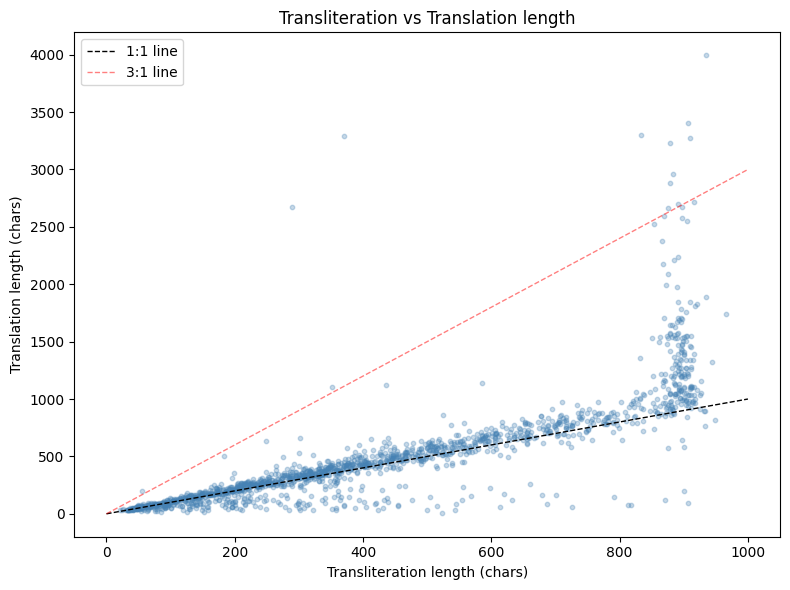

In [48]:
# scatter: transliteration length vs translation length
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['translit_len'], df['transl_len'], alpha=0.3, s=10, color='steelblue')
ax.plot([0, 1000], [0, 1000], 'k--', linewidth=1, label='1:1 line')
ax.plot([0, 1000], [0, 3000], 'r--', linewidth=1, alpha=0.5, label='3:1 line')
ax.set_xlabel('Transliteration length (chars)')
ax.set_ylabel('Translation length (chars)')
ax.set_title('Transliteration vs Translation length')
ax.legend()
plt.tight_layout()
plt.show()


## Qualitative Sample

In [49]:
sample = df.sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f"{'─'*70}")
    print(f"oare_id: {row['oare_id']}")
    print(f"TRANSLIT: {row['transliteration'][:200]}")
    print(f"TRANSLATION: {row['translation'][:200]}")
    print()


──────────────────────────────────────────────────────────────────────
oare_id: f9ff19ef-86d3-477d-abf4-49be2ac7e619
TRANSLIT: 10 ma-na KÙ.BABBAR ṣa-ru-pu-um ni-is-ḫa-sú DIRI ša-du-a-sú ša-bu ša tám-kà-ri-im a-na i-li-a ù ša ki-ma lá-qé-ep ù a-ḫa-ma 0.3333 ma-na KÙ.BABBAR ša ta-ad-mì-iq-tí-šu ša i-li-a 1 GÍN KÙ.BABBAR šé-bu-u
TRANSLATION: 10 minas of refined silver, its excise added, his transport fee paid, belonging to the merchant, for Iliya and the representatives of Lā-qēp, and separately 0.3333 mina of silver from Iliya's free loa

──────────────────────────────────────────────────────────────────────
oare_id: a38d4d84-5c29-4edc-894b-95fe741920bb
TRANSLIT: 2-ší-ta na-áš-pé-ra-tum lá pá-tí-a-tum ša a-ta-ta DUMU ma-num-ba-lum-a-šùr a-ṣé-ri-a ú a-ṣé-er a-šùr-e-nam DUMU ku-bi-a 2-ší-ta na-áš-pé-ra-tum ša a-bi₄-ni lá pá-tí-a-tum a-na be-lúm-ba-ni DUMU šu-be-
TRANSLATION: 2 (unopened) letters of Atata, son of Mannum-balum-Assur, addressed to me and to Assur-ennam, son of Kubiya; two (un

## Summary

| Issue | Count | Action in `preprocessing.py` |
|---|---|---|
| Trailing whitespace (translation) | 143 rows | Strip |
| `""` double-quote artifact | 103 rows | Replace `""` → `"` |
| `<of<gap>` malformed gap variant | 1 row | Normalise → `<gap>` |
| Hebrew char ד | 1 row | Remove / replace with space |
| Curly/smart quotes | ~4 rows | Normalise to straight ASCII |
| Duplicate (translit, translation) pairs | 0 | Nothing to drop |
| Very short translations (< 20 chars) | 4 rows | Flag, keep |
| High length ratio (> 3×) | 13 rows | Flag, keep |
| Low length ratio (< 0.15×) | 23 rows | Flag, keep |

**What is intentionally kept:** `{d}` / `{ki}` determinatives, `<gap>` lacuna tokens, subscript digits, decimal fractions, `+` tablet-join markers, and all Assyriological diacritics (š, ṭ, ḫ, ṣ …).  
These are linguistically meaningful and must survive into the model inputs unchanged.
